# 02 - Exploration

A visual first look at the cleaned data (`data/processed/creditcard_clean.csv`). Every chart is saved as an image file in `outputs/figures`, not just shown here.

`matplotlib.pyplot` is Python's standard charting library; `plt` is the name almost everyone uses for it. `StrMethodFormatter` adds thousands commas to axis numbers. The `sys` check (first explained in notebook 01) confirms the project's own `.venv` Python is running.

In [1]:
import sys

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import StrMethodFormatter

print(sys.executable)

C:\Users\RevathyHarichandran\Desktop\portfolio projects\Fraud_detection\.venv\Scripts\python.exe


In [2]:
transactions = pd.read_csv("../data/processed/creditcard_clean.csv")
print(transactions.shape)

(283726, 32)


## Chart 1: Class balance

Count genuine (0) and fraud (1) transactions and work out fraud's percentage, straight from the data.

In [3]:
class_counts = transactions["Class"].value_counts()
genuine_count = class_counts[0]
fraud_count = class_counts[1]
total_count = genuine_count + fraud_count
fraud_percent = fraud_count / total_count * 100

print(genuine_count, fraud_count, total_count, fraud_percent)

283253 473 283726 0.1667101358352777


Draw the chart on a normal scale starting at zero, so the fraud bar's true size is visible. A log scale would make both bars easy to see but would make a 600-to-1 difference look small, which is exactly the wrong impression.

- `plt.subplots(figsize=(7, 5))` makes a blank chart: `fig` is the whole image, `ax` the plotting area. 7 by 5 inches (default 6.4 by 4.8) gives room for the labels.
- `width=0.5` makes each bar half its slot (default 0.8), leaving clear space between just two bars.
- Colours: blue for genuine, orange for fraud, from a palette checked to stay distinguishable for colour-blind readers. The bar names and count labels mean colour is never the only way to tell them apart.
- `bar_label` writes each count at its bar's tip. The text is built with **f-strings**: `f"{fraud_count:,}"` puts the number into text, and `:,` adds thousands commas; `:.2f` shows 2 decimal places.
- Faint horizontal gridlines help read heights; the top and right borders are removed because they carry no information.

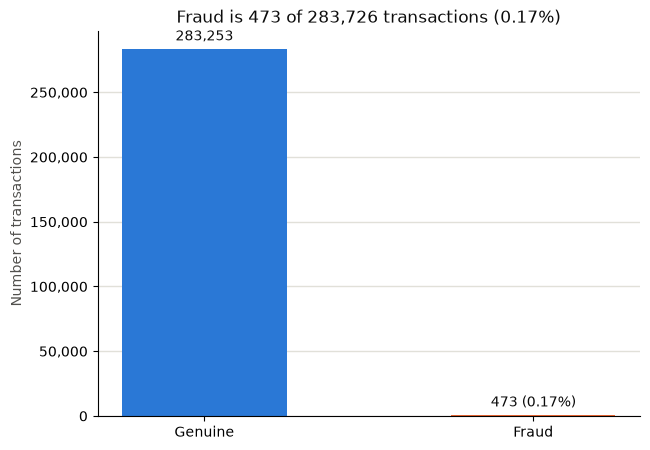

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))

bar_names = ["Genuine", "Fraud"]
bar_heights = [genuine_count, fraud_count]
bar_colors = ["#2a78d6", "#eb6834"]
bars = ax.bar(bar_names, bar_heights, color=bar_colors, width=0.5)

genuine_label = f"{genuine_count:,}"
fraud_label = f"{fraud_count:,} ({fraud_percent:.2f}%)"
ax.bar_label(bars, labels=[genuine_label, fraud_label], padding=4, color="#0b0b0b")

ax.set_title(f"Fraud is {fraud_count:,} of {total_count:,} transactions ({fraud_percent:.2f}%)", color="#0b0b0b")
ax.set_ylabel("Number of transactions", color="#52514e")
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))

ax.grid(axis="y", color="#e1e0d9", linewidth=1)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

Save it as a real image file. `dpi=150` (dots per inch) makes a sharp 1,050 x 750 pixel image; the default is the figure's own 100, which can look slightly soft. `bbox_inches="tight"` trims empty margins so no label is cut off. PNG keeps text and bar edges sharp (JPG can smudge them).

In [5]:
fig.savefig("../outputs/figures/01_class_balance.png", dpi=150, bbox_inches="tight")
plt.show()

**What this shows:** of 283,726 cleaned transactions, only 473 are fraud (0.17%), about 1 for every 599 genuine ones. On a true scale the fraud bar is roughly 600 times shorter than the genuine bar and shows only as a sliver. A model that called every transaction genuine would be 99.8% "accurate" while catching no fraud at all, which is why accuracy is never this project's main measure.

## Chart 2: Amount distribution and skewness

Summary numbers first. The **median** is the middle value (half the transactions are smaller, half bigger). `quantile(0.99)` is the **99th percentile**: the amount below which 99% of transactions fall. If a few huge amounts drag the mean well above the median, the data leans to the right.

In [6]:
amount = transactions["Amount"]

amount_min = amount.min()
amount_median = amount.median()
amount_mean = amount.mean()
amount_p99 = amount.quantile(0.99)
amount_max = amount.max()

print("smallest:", amount_min)
print("median:", amount_median)
print("mean:", amount_mean)
print("99th percentile:", amount_p99)
print("largest:", amount_max)

smallest: 0.0
median: 22.0
mean: 88.47268731099723
99th percentile: 1018.965
largest: 25691.16


**Skewness**: one number for how lopsided the data is. 0 is symmetric; positive means a long tail to the right (many small values, a few very large ones). A common rule of thumb: beyond ±1 is "highly skewed", 0.5 to 1 "moderately skewed".

pandas' `skew()` uses a slightly adjusted formula that corrects for sample size. To check it, we also calculate it step by step:
1. each amount's distance from the mean,
2. cubed (`** 3` means "to the power of 3"); cubing keeps minus signs, so big values far above the mean push the total up hard,
3. averaged,
4. divided by the standard deviation cubed. Here the standard deviation is calculated the plain way, dividing by the number of rows (`ddof=0`); pandas' default `std()` divides by one less (`ddof=1`).

With this many rows, the two answers should agree to several decimal places.

In [7]:
skew_pandas = amount.skew()

distance_from_mean = amount - amount_mean
cubed_distance = distance_from_mean ** 3
average_cubed_distance = cubed_distance.mean()
plain_std = amount.std(ddof=0)
skew_by_hand = average_cubed_distance / plain_std ** 3

print("skewness (pandas):", skew_pandas)
print("skewness (by hand):", skew_by_hand)

skewness (pandas): 16.978803370060476
skewness (by hand): 16.9787136065476


The chart has two panels. **Left:** every transaction, full range, showing the long tail. **Right:** zoomed in to the 99th percentile, where 99% of transactions sit; the rest are left out of this *picture* only, never removed from the data. A log scale would also un-squash the picture but would disguise the very lopsidedness we want to show.

- `plt.subplots(1, 2, figsize=(12, 5))` makes one row of two plotting areas; `axes[0]` is the left one, `axes[1]` the right.
- `hist(..., bins=50)` splits the range into 50 equal slices and counts transactions in each (matplotlib's default is 10, too coarse to show where most amounts sit).
- One colour, since it is one series. Thin vertical lines mark the median and mean on the zoomed panel (`axvline` draws a vertical line). The two lines sit too close together for text to fit between them, so a small **legend** (`legend`) in the empty top-right corner names each one, using the `label` given to each line. `frameon=False` drops the legend's box, which would be extra ink carrying no information.
- Boolean filtering (notebook 01, Step 4) selects the amounts up to the 99th percentile.

Text(0.5, 0.98, 'Distribution of Amount (skewness 16.98)')

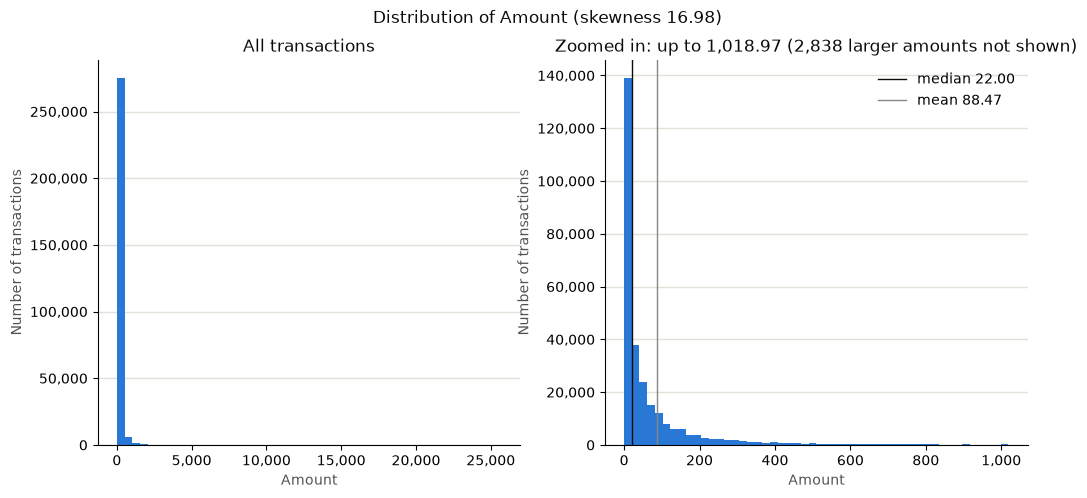

In [8]:
is_within_p99 = amount <= amount_p99
amount_within_p99 = amount[is_within_p99]
number_beyond_p99 = len(amount) - len(amount_within_p99)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
left_ax = axes[0]
right_ax = axes[1]

# Left panel: every transaction.
left_ax.hist(amount, bins=50, color="#2a78d6")
left_ax.set_title("All transactions", color="#0b0b0b")

# Right panel: zoomed in to the 99th percentile.
right_ax.hist(amount_within_p99, bins=50, color="#2a78d6")
right_ax.set_title(f"Zoomed in: up to {amount_p99:,.2f} ({number_beyond_p99:,} larger amounts not shown)", color="#0b0b0b")

# Median and mean lines. They sit too close together for text labels to fit
# between them, so a small legend in the empty top-right corner names them.
right_ax.axvline(amount_median, color="#0b0b0b", linewidth=1, label=f"median {amount_median:,.2f}")
right_ax.axvline(amount_mean, color="#898781", linewidth=1, label=f"mean {amount_mean:,.2f}")
right_ax.legend(frameon=False, loc="upper right")

# Shared tidying for both panels, using a for loop (first explained in notebook 01).
for ax in axes:
    ax.set_xlabel("Amount", color="#52514e")
    ax.set_ylabel("Number of transactions", color="#52514e")
    ax.xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
    ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
    ax.grid(axis="y", color="#e1e0d9", linewidth=1)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle(f"Distribution of Amount (skewness {skew_pandas:.2f})", color="#0b0b0b")

In [9]:
fig.savefig("../outputs/figures/02_amount_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

**What this shows:** Amount is heavily right-skewed, with a skewness of 16.98 (the "highly skewed" rule of thumb starts at 1). Half of all transactions are 22.00 or less, but the mean is 88.47, four times the median, because a small number of very large amounts pull the average up. 99% of transactions are 1,018.97 or less, yet the largest is 25,691.16. In practice: Amount needs scaling (fitted on training data only) before scale-sensitive models such as Logistic Regression.

## Outliers in Amount (IQR rule)

Not "is this value impossible?" (Phase 1 already showed no negatives), but "is it unusually extreme?".

1. **Q1** (25th percentile): a quarter of amounts are this or less. **Q3** (75th percentile): three quarters are.
2. **IQR** = Q3 − Q1, the width of the middle half of the data.
3. **Fences**: lower = Q1 − 1.5 × IQR, upper = Q3 + 1.5 × IQR. Anything outside is an outlier. 1.5 is John Tukey's convention (also where boxplot whiskers stop); he called beyond **3 × IQR** "far out", so both are reported.

Why not z-scores (more than 3 standard deviations from the mean)? On data this skewed, the huge amounts inflate the mean and standard deviation themselves, partly hiding the values being looked for. Q1 and Q3 are barely moved by the extreme tail.

`quantile()` default relied on: when a quarter point falls between two actual values, pandas draws a straight line between them (`interpolation="linear"`).

In [10]:
q1 = amount.quantile(0.25)
q3 = amount.quantile(0.75)
iqr = q3 - q1

lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr
far_out_fence = q3 + 3 * iqr

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("lower fence (1.5 x IQR):", lower_fence)
print("upper fence (1.5 x IQR):", upper_fence)
print("far-out fence (3 x IQR):", far_out_fence)

Q1: 5.6
Q3: 77.51
IQR: 71.91000000000001
lower fence (1.5 x IQR): -102.26500000000001
upper fence (1.5 x IQR): 185.375
far-out fence (3 x IQR): 293.24


Count the transactions outside each fence, and each as a percentage of all transactions. On data this skewed, "outlier" means "unusually large compared with the typical transaction", not "wrong".

In [11]:
is_below_lower = amount < lower_fence
is_above_upper = amount > upper_fence
is_far_out = amount > far_out_fence

below_lower_count = is_below_lower.sum()
above_upper_count = is_above_upper.sum()
far_out_count = is_far_out.sum()

print("below lower fence:", below_lower_count)
print("above upper fence (1.5 x IQR):", above_upper_count, f"({above_upper_count / len(amount) * 100:.2f}%)")
print("above far-out fence (3 x IQR):", far_out_count, f"({far_out_count / len(amount) * 100:.2f}%)")

below lower fence: 0
above upper fence (1.5 x IQR): 31685 (11.17%)
above far-out fence (3 x IQR): 18802 (6.63%)


Are large transactions more or less likely to be fraud? Compare the fraud count and rate among the upper outliers with all other transactions. Because `Class` is 1 for fraud and 0 for genuine, adding it up counts the fraud rows (notebook 01, Step 8), so its **mean** (that sum divided by the number of rows) is the share of rows that are fraud. Multiplying by 100 gives a percentage.

In [12]:
outlier_rows = transactions[is_above_upper]
other_rows = transactions[~is_above_upper]

print("Upper outliers:")
print(outlier_rows["Class"].value_counts())
print(f"fraud rate: {outlier_rows['Class'].mean() * 100:.3f}%")
print()
print("All other transactions:")
print(other_rows["Class"].value_counts())
print(f"fraud rate: {other_rows['Class'].mean() * 100:.3f}%")

Upper outliers:
Class
0    31598
1       87
Name: count, dtype: int64
fraud rate: 0.275%

All other transactions:
Class
0    251655
1       386
Name: count, dtype: int64
fraud rate: 0.153%


The 5 largest transactions, with `row_id` and `Class`. `nlargest(5, "Amount")` picks the 5 rows with the biggest Amount (the same result as sorting the whole table and taking the top 5, with less work).

In [13]:
largest_five = transactions.nlargest(5, "Amount")
print(largest_five[["row_id", "Time", "Amount", "Class"]])

        row_id      Time    Amount  Class
273745  274771  166198.0  25691.16      0
58220    58465   48401.0  19656.53      0
150705  151296   95286.0  18910.00      0
46641    46841   42951.0  12910.93      0
53784    54018   46253.0  11898.09      0


### Chart 3: the IQR rule as a boxplot

The box spans Q1 to Q3, the line inside is the median, the whisker stops at the last amount inside the upper fence, and every dot beyond is an upper outlier. `whis=1.5` sets the fences at 1.5 × IQR; that is also matplotlib's default, written out so the rule is visible in the code. The boxplot is drawn sideways (`orientation="horizontal"`) so Amount reads left to right, matching the histograms. `patch_artist=True` lets the box be filled with colour (by default it is an outline only).

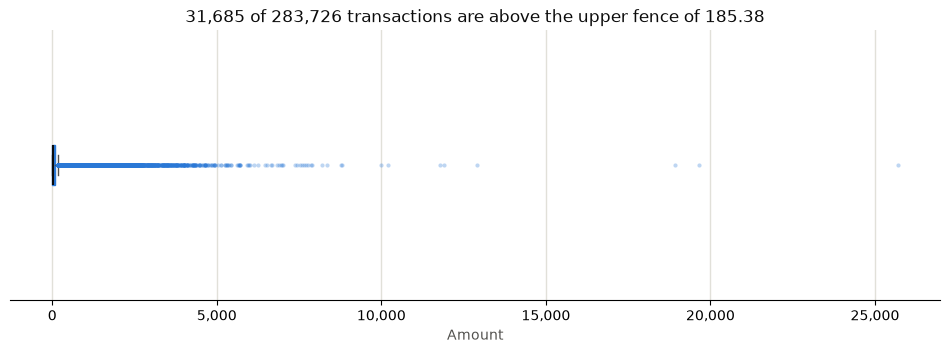

In [14]:
fig, ax = plt.subplots(figsize=(12, 3.5))

# Style settings for each part of the boxplot, written as dictionaries
# (pairs of setting name and value inside curly brackets).
box_style = {"facecolor": "#2a78d6", "edgecolor": "#2a78d6"}
median_style = {"color": "#0b0b0b", "linewidth": 1.5}
line_style = {"color": "#52514e", "linewidth": 1}
# Outlier dots: small, and partly see-through (alpha=0.3) so that where
# thousands of dots pile up, the darker areas show how dense they are.
dot_style = {"marker": "o", "markersize": 3, "markerfacecolor": "#2a78d6",
             "markeredgecolor": "none", "alpha": 0.3}

ax.boxplot(amount, whis=1.5, orientation="horizontal", patch_artist=True,
           boxprops=box_style, medianprops=median_style,
           whiskerprops=line_style, capprops=line_style, flierprops=dot_style)

ax.set_title(f"{above_upper_count:,} of {len(amount):,} transactions are above the upper fence of {upper_fence:,.2f}", color="#0b0b0b")
ax.set_xlabel("Amount", color="#52514e")
ax.set_yticks([])
ax.xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.grid(axis="x", color="#e1e0d9", linewidth=1)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

fig.savefig("../outputs/figures/03_amount_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

Decision: **all outliers are kept**. They are real transactions, not errors; on data this skewed the IQR rule flags ordinary larger purchases. Removing them would discard 11% of the data and 87 fraud cases (18% of all fraud), and large amounts are about 1.8 times as likely to be fraud (0.275% against 0.153%), so removal would throw away signal the model should learn. Amount is scaled later, fitted on training data only, for scale-sensitive models.

## Chart 4: Time distribution, and does fraud follow the same rhythm?

`Time` counts seconds since the first transaction, not the time of day, and the clock time of that first transaction isn't given. So a quiet stretch can't be labelled "night". What can be tested: do busy and quiet stretches repeat about **24 hours apart**?

`//` is **floor division**: divide, then drop everything after the decimal point. `Time // 3600` turns seconds into a whole hour number from 0 to 47 (a transaction at 5,000 seconds, 1.39 hours in, goes into hour 1). `value_counts()` sorts busiest first by default, so `sort_index()` puts the hours back in time order.

In [15]:
hour_number = transactions["Time"] // 3600
hourly_counts = hour_number.value_counts().sort_index()

print(len(hourly_counts))
print(hourly_counts)

48


Time
0.0     3931
1.0     2213
2.0     1573
3.0     1818
4.0     1082
5.0     1679
6.0     1822
7.0     3366
8.0     5148
9.0     7841
10.0    8246
11.0    8474
12.0    7703
13.0    7565
14.0    8012
15.0    7807
16.0    7770
17.0    7874
18.0    8548
19.0    7945
20.0    8946
21.0    9875
22.0    8943
23.0    6055
24.0    3716
25.0    1995
26.0    1735
27.0    1669
28.0    1122
29.0    1309
30.0    2260
31.0    3867
32.0    5084
33.0    7926
34.0    8302
35.0    8307
36.0    7675
37.0    7758
38.0    8508
39.0    8567
40.0    8626
41.0    8256
42.0    8411
43.0    7621
44.0    7759
45.0    7754
46.0    6435
47.0    4828
Name: count, dtype: int64


Measure the rhythm instead of eyeballing it. Split the hours into the first 24 (hours 0 to 23) and the second 24 (hours 24 to 47), and find the quietest hour in each. `idxmin()` gives the hour number (the label) of the smallest count. If the two quiet hours are about 24 hours apart, that supports a daily cycle. `hourly_counts[hourly_counts.index < 24]` is boolean filtering on the hour labels (the index).

In [16]:
first_day = hourly_counts[hourly_counts.index < 24]
second_day = hourly_counts[hourly_counts.index >= 24]

quietest_first = first_day.idxmin()
quietest_second = second_day.idxmin()

print("quietest hour, first 24:", quietest_first, "with", first_day.min(), "transactions")
print("quietest hour, second 24:", quietest_second, "with", second_day.min(), "transactions")
print("hours apart:", quietest_second - quietest_first)
print()
print("busiest hour overall:", hourly_counts.idxmax(), "with", hourly_counts.max(), "transactions")
print("quietest hour overall:", hourly_counts.idxmin(), "with", hourly_counts.min(), "transactions")

quietest hour, first 24: 4.0 with 1082 transactions
quietest hour, second 24: 28.0 with 1122 transactions
hours apart: 24.0

busiest hour overall: 21.0 with 9875 transactions
quietest hour overall: 4.0 with 1082 transactions


**Fraud rate per hour.** `groupby(hour_number)` splits the rows into 48 groups, one per hour; `.mean()` of `Class` in each group is that hour's fraud share (the same idea as above: Class is 1 for fraud, so its mean is the fraud share), and `.sum()` counts that hour's fraud cases. `groupby` is the general tool for "do the same calculation separately for each group".

Caveat: 473 fraud cases over 48 hours is about 10 per hour, so an hour's rate can swing a lot on a handful of cases. Any pattern here is tentative.

In [17]:
fraud_rate_per_hour = transactions["Class"].groupby(hour_number).mean() * 100
fraud_count_per_hour = transactions["Class"].groupby(hour_number).sum()

print("highest fraud rate:", fraud_rate_per_hour.idxmax(), f"{fraud_rate_per_hour.max():.3f}%",
      "from", fraud_count_per_hour[fraud_rate_per_hour.idxmax()], "fraud cases")
print("lowest fraud rate:", fraud_rate_per_hour.idxmin(), f"{fraud_rate_per_hour.min():.3f}%",
      "from", fraud_count_per_hour[fraud_rate_per_hour.idxmin()], "fraud cases")

highest fraud rate: 26.0 1.556% from 27 fraud cases
lowest fraud rate: 29.0 0.000% from 0 fraud cases


The chart: two panels stacked, sharing the same hour axis (`sharex=True`, so the hours line up exactly). They are separate panels, not two sets of bars on one chart, because a count and a percentage are different kinds of number and would need two y-axes, which misleads.

- **Top:** transactions per hour, one bar per hour (`width=0.9` leaves a small gap between neighbouring hours).
- **Bottom:** fraud rate per hour, in the fraud colour, with a horizontal line (`axhline`) at the overall fraud rate for comparison.
- A thin vertical line at hour 24 on both marks "24 hours after the first transaction". It is deliberately not labelled "midnight", because the clock time isn't known.

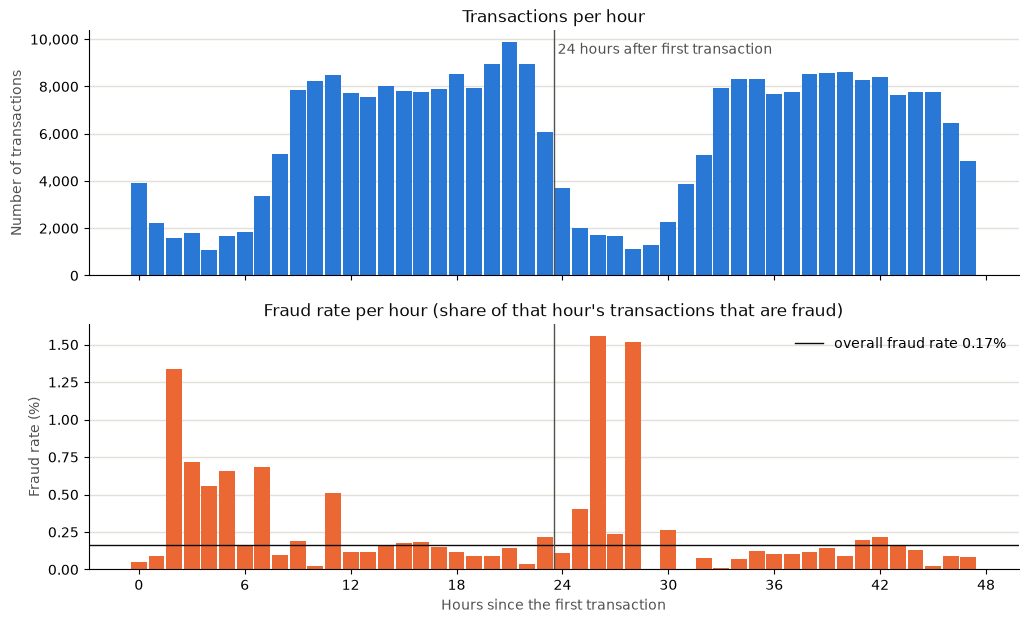

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
top_ax = axes[0]
bottom_ax = axes[1]

# Top panel: transactions per hour.
top_ax.bar(hourly_counts.index, hourly_counts.values, width=0.9, color="#2a78d6")
top_ax.set_title("Transactions per hour", color="#0b0b0b")
top_ax.set_ylabel("Number of transactions", color="#52514e")
top_ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))

# Bottom panel: fraud rate per hour, with the overall rate for comparison.
bottom_ax.bar(fraud_rate_per_hour.index, fraud_rate_per_hour.values, width=0.9, color="#eb6834")
bottom_ax.axhline(fraud_percent, color="#0b0b0b", linewidth=1, label=f"overall fraud rate {fraud_percent:.2f}%")
bottom_ax.legend(frameon=False, loc="upper right")
bottom_ax.set_title("Fraud rate per hour (share of that hour's transactions that are fraud)", color="#0b0b0b")
bottom_ax.set_ylabel("Fraud rate (%)", color="#52514e")
bottom_ax.set_xlabel("Hours since the first transaction", color="#52514e")

# Shared tidying, plus the hour-24 marker on both panels. Each bar is centred
# on its hour number, so the boundary between hour 23 and hour 24 is at 23.5.
for ax in axes:
    ax.axvline(23.5, color="#52514e", linewidth=1)
    ax.grid(axis="y", color="#e1e0d9", linewidth=1)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

top_ax.text(23.5, top_ax.get_ylim()[1] * 0.95, " 24 hours after first transaction", color="#52514e", va="top")
bottom_ax.set_xticks(range(0, 49, 6))

fig.savefig("../outputs/figures/04_time_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

**What this shows:**
- **A clear daily cycle.** The quietest hours are exactly 24 hours apart (hour 4 with 1,082 transactions, hour 28 with 1,122), against up to 9,875 in the busiest hour (hour 21), about 9 times as many. The quiet stretches are consistent with night-time, but the clock time isn't known, so they can't be labelled "night" for certain.
- **Fraud does not follow the same rhythm.** During busy hours the fraud rate stays close to the overall 0.17%. During both quiet periods it jumps: about 1.3% in hour 2 and about 1.5% in hours 26 and 28 (hour 26: 27 fraud out of 1,735 transactions, 1.556%). Genuine spending drops away at night while fraud continues, so fraud becomes a much bigger share.
- **Caveat:** single hours rest on few fraud cases (hour 29 had none), so individual bars are noisy; the pattern is believable because it appears in both quiet periods, on both days. No formal test was run.
- **Idea to test in Phase 5** (recorded in DECISIONS.md): an hour-of-day feature (hour number modulo 24), which lines the two days up so a model can learn "these hours are riskier". Kept only if it genuinely helps on the validation data.

## Chart 5: Does fraud look different in Amount?

### The table

`groupby("Class")` (first used for the Time chart) splits the rows into genuine and fraud, and each statistic is calculated per group. `pd.DataFrame({...})` then builds one table from a dictionary: each name becomes a column heading, each result that column's values.

Two measures of spread: the **standard deviation** is stretched badly by a few huge amounts, so on skewed data like this the **IQR** (Q3 − Q1) is the more trustworthy one. Both are shown. The last two columns tie back to earlier findings: the share of exactly-zero amounts (notebook 01) and the share above the 185.38 outlier fence.

In [19]:
grouped_amount = transactions.groupby("Class")["Amount"]

# True/False columns, grouped the same way; their mean is the share that is True.
is_zero_amount = transactions["Amount"] == 0
is_above_fence = transactions["Amount"] > upper_fence
percent_zero = is_zero_amount.groupby(transactions["Class"]).mean() * 100
percent_above_fence = is_above_fence.groupby(transactions["Class"]).mean() * 100

amount_by_class = pd.DataFrame({
    "count": grouped_amount.count(),
    "mean": grouped_amount.mean(),
    "median": grouped_amount.median(),
    "std": grouped_amount.std(),
    "Q1": grouped_amount.quantile(0.25),
    "Q3": grouped_amount.quantile(0.75),
    "IQR": grouped_amount.quantile(0.75) - grouped_amount.quantile(0.25),
    "min": grouped_amount.min(),
    "max": grouped_amount.max(),
    "percent_zero": percent_zero,
    "percent_above_185.38": percent_above_fence,
})

# Rename the rows from 0 and 1 to plain words.
amount_by_class = amount_by_class.rename(index={0: "Genuine", 1: "Fraud"})
amount_by_class = amount_by_class.round(2)

print(amount_by_class.T)

Class                   Genuine    Fraud
count                 283253.00   473.00
mean                      88.41   123.87
median                    22.00     9.82
std                      250.38   260.21
Q1                         5.67     1.00
Q3                        77.46   105.89
IQR                       71.79   104.89
min                        0.00     0.00
max                    25691.16  2125.87
percent_zero               0.63     5.29
percent_above_185.38      11.16    18.39


In the cell above: `rename(index={0: "Genuine", 1: "Fraud"})` swaps the row labels for plain words; `round(2)` keeps 2 decimal places, enough for money; `.T` (transpose) only flips rows and columns for printing, so the 11 statistics read down the page instead of across it.

Save the table as a real file in `outputs/tables`, next to `outputs/figures` (a table isn't a figure). CSV, so it opens in Excel or Python. Here the row labels (Genuine, Fraud) *are* useful, so the index is kept (the default, `index=True`), unlike the data files in notebook 01. `index_label="group"` gives that label column a heading; by default it would be left blank.

In [20]:
amount_by_class.to_csv("../outputs/tables/amount_by_class.csv", index_label="group")

### The chart

With 283,253 genuine and only 473 fraud transactions, histograms of *counts* would make the fraud bars invisible. Instead each panel shows **percentages of its own group**: `weights` makes each transaction count as 100 ÷ (group size) percent instead of 1, so each panel's bars add up to 100% of that group (minus the share beyond the x-axis), and the two *shapes* can be compared directly. `[value] * n` makes a list holding the same value n times, one weight per transaction.

- Two panels stacked (genuine blue on top, fraud orange below) with **identical bins** and the same x-axis (`sharex=True`), so a bar in one lines up with the same amount range in the other.
- The x-axis stops at the overall 99th percentile (1,018.97); each panel's title says how many of *its* transactions lie beyond it.
- `bin_edges` sets the same 50 equal slices from 0 to the 99th percentile for both panels: a loop over 0 to 50 builds the 51 edges that make 50 bins.
- A median line in each panel.

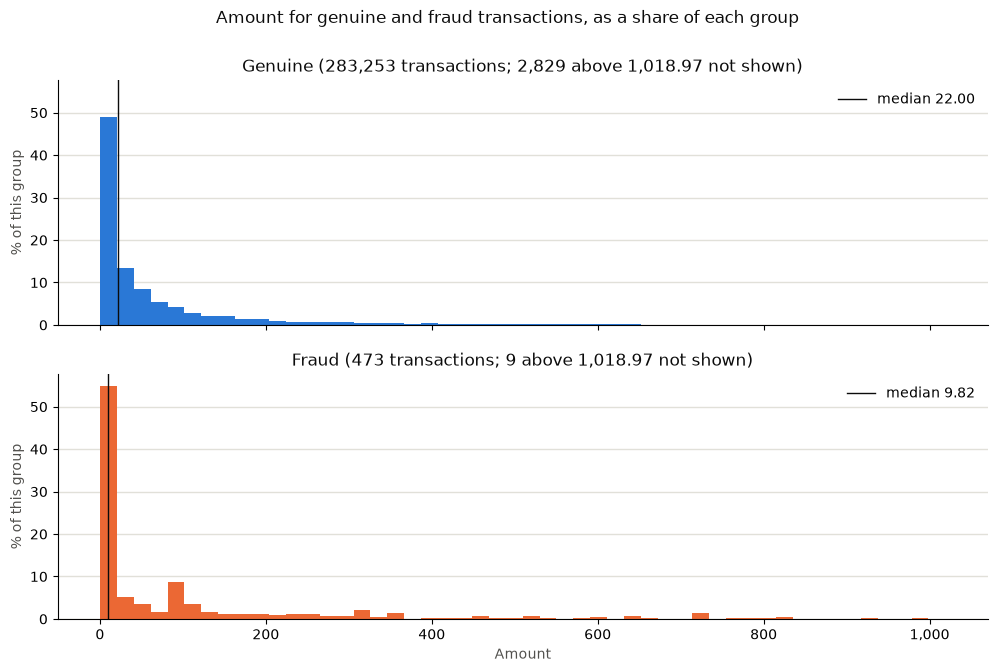

In [21]:
genuine_amounts = transactions[transactions["Class"] == 0]["Amount"]
fraud_amounts = transactions[transactions["Class"] == 1]["Amount"]

bin_edges = []
for step in range(51):
    bin_edges.append(step / 50 * amount_p99)

genuine_weights = [100 / len(genuine_amounts)] * len(genuine_amounts)
fraud_weights = [100 / len(fraud_amounts)] * len(fraud_amounts)

genuine_beyond = (genuine_amounts > amount_p99).sum()
fraud_beyond = (fraud_amounts > amount_p99).sum()

# sharey=True gives both panels the same y-axis scale, so bar heights can be
# compared directly between genuine and fraud.
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, sharey=True)
top_ax = axes[0]
bottom_ax = axes[1]

top_ax.hist(genuine_amounts, bins=bin_edges, weights=genuine_weights, color="#2a78d6")
top_ax.axvline(genuine_amounts.median(), color="#0b0b0b", linewidth=1, label=f"median {genuine_amounts.median():,.2f}")
top_ax.set_title(f"Genuine ({len(genuine_amounts):,} transactions; {genuine_beyond:,} above {amount_p99:,.2f} not shown)", color="#0b0b0b")

bottom_ax.hist(fraud_amounts, bins=bin_edges, weights=fraud_weights, color="#eb6834")
bottom_ax.axvline(fraud_amounts.median(), color="#0b0b0b", linewidth=1, label=f"median {fraud_amounts.median():,.2f}")
bottom_ax.set_title(f"Fraud ({len(fraud_amounts):,} transactions; {fraud_beyond:,} above {amount_p99:,.2f} not shown)", color="#0b0b0b")
bottom_ax.set_xlabel("Amount", color="#52514e")
bottom_ax.xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))

for ax in axes:
    ax.set_ylabel("% of this group", color="#52514e")
    ax.legend(frameon=False, loc="upper right")
    ax.grid(axis="y", color="#e1e0d9", linewidth=1)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("Amount for genuine and fraud transactions, as a share of each group", color="#0b0b0b")

fig.savefig("../outputs/figures/05_amount_by_class.png", dpi=150, bbox_inches="tight")
plt.show()

### Is the difference real, or could it be luck? A bootstrap confidence interval

With only 473 fraud cases, a different set of fraud cases could have given a different median. The **bootstrap** measures how much:

1. Pretend our fraud amounts are the whole world. Draw the same number of amounts from them at random **with replacement** (the same transaction can be picked more than once, some not at all). That is one "resample": a version of the fraud group we could have ended up with.
2. Calculate its median (and mean).
3. Repeat 1,000 times.
4. The middle 95% of those 1,000 medians (cutting off the lowest 2.5% and highest 2.5%) is the **95% confidence interval**: the range where the true median plausibly sits.
5. Same for genuine transactions.

If the fraud and genuine intervals don't overlap, the difference is very unlikely to be luck.

Choices: **1,000 resamples** gives stable 95% intervals (10,000 would be slightly more precise but slow for 283,253 genuine amounts, for no meaningful gain). A **random seed** (42) makes the "random" draws the same on every run, so the numbers are reproducible; the value itself doesn't matter. **numpy** (the number library pandas is built on, already installed) does the drawing: `rng.choice(values, size=n, replace=True)` draws n values with replacement, and `np.percentile(results, 2.5)` finds the value 2.5% of the way up.

In [22]:
import numpy as np

number_of_resamples = 1000
rng = np.random.default_rng(42)

# to_numpy() hands numpy the plain list of numbers, which it resamples fastest.
fraud_values = fraud_amounts.to_numpy()
genuine_values = genuine_amounts.to_numpy()

fraud_medians = []
fraud_means = []
for resample_number in range(number_of_resamples):
    resample = rng.choice(fraud_values, size=len(fraud_values), replace=True)
    fraud_medians.append(np.median(resample))
    fraud_means.append(np.mean(resample))

genuine_medians = []
genuine_means = []
for resample_number in range(number_of_resamples):
    resample = rng.choice(genuine_values, size=len(genuine_values), replace=True)
    genuine_medians.append(np.median(resample))
    genuine_means.append(np.mean(resample))

print(f"Fraud median:   {np.median(fraud_values):.2f}   95% CI {np.percentile(fraud_medians, 2.5):.2f} to {np.percentile(fraud_medians, 97.5):.2f}")
print(f"Genuine median: {np.median(genuine_values):.2f}   95% CI {np.percentile(genuine_medians, 2.5):.2f} to {np.percentile(genuine_medians, 97.5):.2f}")
print()
print(f"Fraud mean:     {np.mean(fraud_values):.2f}  95% CI {np.percentile(fraud_means, 2.5):.2f} to {np.percentile(fraud_means, 97.5):.2f}")
print(f"Genuine mean:   {np.mean(genuine_values):.2f}   95% CI {np.percentile(genuine_means, 2.5):.2f} to {np.percentile(genuine_means, 97.5):.2f}")

Fraud median:   9.82   95% CI 6.98 to 19.60
Genuine median: 22.00   95% CI 21.95 to 22.37

Fraud mean:     123.87  95% CI 101.81 to 149.09
Genuine mean:   88.41   95% CI 87.50 to 89.31


**What this shows:** yes, fraud looks different in Amount, and not simply "bigger".
- **The typical fraud is smaller.** Fraud median 9.82 (95% CI 6.98 to 19.60) against genuine 22.00 (21.95 to 22.37). The intervals don't overlap, so this is very unlikely to be luck. A quarter of fraud is 1.00 or less, and 5.29% of fraud is exactly zero, against 0.63% of genuine.
- **But the average fraud is larger.** Fraud mean 123.87 (101.81 to 149.09) against genuine 88.41 (87.50 to 89.31); again no overlap. 18.39% of fraud is above the 185.38 outlier fence, against 11.16% of genuine.
- **So fraud is more polarised:** more very small amounts *and* more large ones, with less in between. The median and mean point in opposite directions, which is why neither alone would tell the whole story.
- **Fraud has no extreme tail:** the largest fraud is 2,125.87, while genuine goes up to 25,691.16.
- The standard deviations are similar (250.38 and 260.21) and say little here, because both are stretched by the tail; the IQRs (71.79 against 104.89) show fraud's middle half is more spread out.

## Chart 6: Correlation heatmap of V1 to V28 (plus Time and Amount for contrast)

**Correlation** is a number from −1 to +1 for how closely two columns move together: +1 in step, −1 in opposite steps, 0 no straight-line relationship. `corr()` uses **Pearson** correlation by default, which measures straight-line relationships.

**What PCA predicts:** PCA builds its columns one at a time, each capturing variation none of the earlier ones captured. That forces every pair of PCA columns to have a correlation of exactly 0 on the data PCA was fitted on. So V-versus-V correlations should be almost 0. Not *exactly* 0 here, because 1,081 duplicate rows were removed in notebook 01, and the creators may have fitted PCA on slightly different rows.

**The contrast:** Time and Amount were never put through PCA, so nothing forces them to be uncorrelated with the V columns. They are added at the end.

First, the V column names, built with the same `for` loop as notebook 01, Step 6 (see there for the full explanation).

In [23]:
v_columns = []
for number in range(1, 29):
    v_columns.append("V" + str(number))

heatmap_columns = v_columns + ["Time", "Amount"]
correlations = transactions[heatmap_columns].corr()

print(correlations.shape)

(30, 30)


Find the largest correlation between two *different* V columns, ignoring minus signs (`abs()`). This uses a **nested loop**, a loop inside a loop: the outer loop picks one V column, the inner loop goes through every V column *after* it (`range(first + 1, 28)`), so each of the 378 pairs is visited exactly once and no column is compared with itself. `correlations.loc[row_name, column_name]` reads one cell of the table by its row and column names.

Then, for contrast, the largest correlation between Time and any V column, and between Amount and any V column.

In [24]:
largest_v_correlation = 0
largest_v_pair = ""
number_of_pairs = 0

for first in range(28):
    for second in range(first + 1, 28):
        first_name = v_columns[first]
        second_name = v_columns[second]
        value = correlations.loc[first_name, second_name]
        number_of_pairs = number_of_pairs + 1
        if abs(value) > abs(largest_v_correlation):
            largest_v_correlation = value
            largest_v_pair = first_name + " and " + second_name

print("pairs checked:", number_of_pairs)
print("largest V-versus-V correlation:", largest_v_pair, largest_v_correlation)
print()

time_with_v = correlations.loc["Time", v_columns]
amount_with_v = correlations.loc["Amount", v_columns]
strongest_time = time_with_v.abs().idxmax()
strongest_amount = amount_with_v.abs().idxmax()

print("largest Time-versus-V correlation:", strongest_time, time_with_v[strongest_time])
print("largest Amount-versus-V correlation:", strongest_amount, amount_with_v[strongest_amount])

pairs checked: 378
largest V-versus-V correlation: V8 and V21 0.018892285715434554

largest Time-versus-V correlation: V3 -0.42205381041134654
largest Amount-versus-V correlation: V2 -0.533428013926673


The heatmap: `imshow` draws the table as a grid of coloured squares.

- **Colours:** blue for negative, a neutral grey for 0, red for positive, joined into a smooth scale with `LinearSegmentedColormap.from_list`. The middle is neutral so "no correlation" reads as "nothing". (matplotlib's built-in "RdBu" uses a white middle, which would blend into the page.)
- **The colour scale is fixed from −1 to +1** (`vmin=-1, vmax=1`). Without this, matplotlib stretches the colours to fit whatever values exist, so tiny correlations like 0.001 would be painted strong red or blue and the chart would show relationships that aren't there. Fixed, a grey square honestly means "close to zero".
- A **colour bar** at the side shows which colour means which value. No numbers are written in the squares (900 would be unreadable); the largest ones are printed above.
- The tick labels name every column; `rotation=90` turns the bottom ones sideways so they don't overlap.

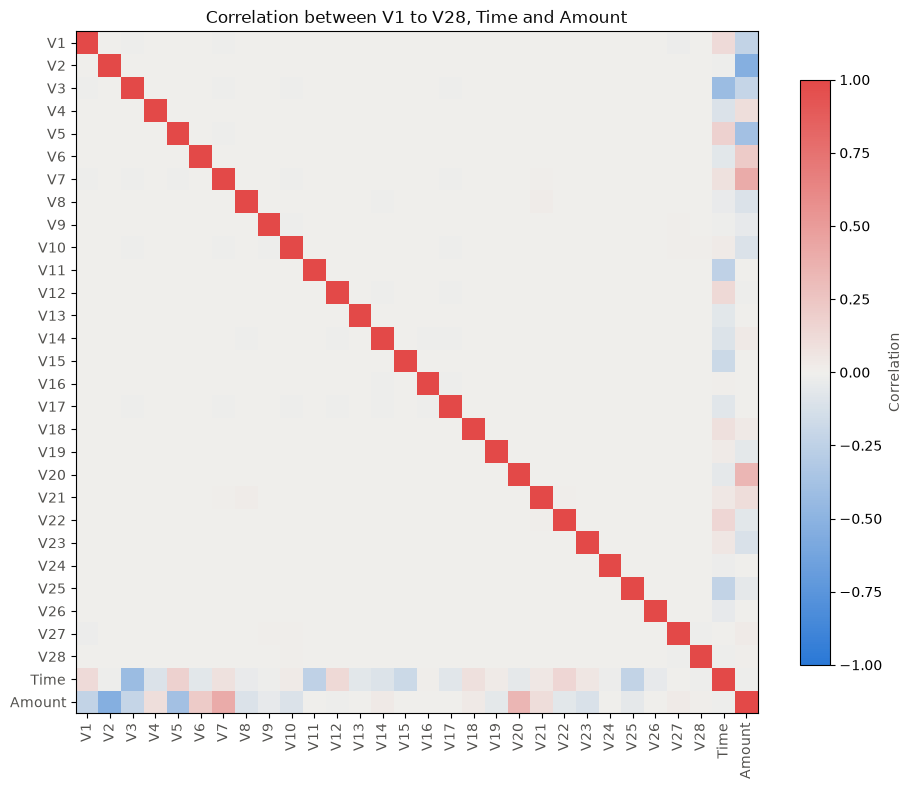

In [25]:
from matplotlib.colors import LinearSegmentedColormap

diverging_colors = LinearSegmentedColormap.from_list("blue_grey_red", ["#2a78d6", "#f0efec", "#e34948"])

fig, ax = plt.subplots(figsize=(11, 9.5))
image = ax.imshow(correlations, cmap=diverging_colors, vmin=-1, vmax=1)

ax.set_xticks(range(len(heatmap_columns)))
ax.set_xticklabels(heatmap_columns, rotation=90, color="#52514e")
ax.set_yticks(range(len(heatmap_columns)))
ax.set_yticklabels(heatmap_columns, color="#52514e")

colour_bar = fig.colorbar(image, ax=ax, shrink=0.8)
colour_bar.set_label("Correlation", color="#52514e")

ax.set_title("Correlation between V1 to V28, Time and Amount", color="#0b0b0b")

fig.savefig("../outputs/figures/06_v_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

**What this shows:**
- **V1 to V28 are essentially uncorrelated with each other, exactly as PCA predicts.** Across all 378 pairs, the largest correlation is V8 with V21 at 0.019, almost nothing on a −1 to +1 scale. The V-versus-V area of the heatmap is uniform grey. The red diagonal is each column compared with itself, which is always exactly 1.
- **Why:** PCA builds each column to capture only variation that no earlier column already captured, so the columns carry non-overlapping information. The tiny leftovers (not exactly 0) are consistent with our having removed 1,081 duplicate rows after PCA was applied.
- **The contrast supports this.** Time and Amount were never part of PCA, and they do correlate with some V columns: Time with V3 at −0.42, Amount with V2 at −0.53. So correlation clearly *can* appear in this data; the zeros between V columns come from how PCA built them, not from the data being random. Amount correlating with V columns suggests some of the original confidential details (which went into the V columns) were related to how much was spent.
- **In practice:** no two V columns repeat each other's information, so none needs dropping as redundant.